In [4]:
# %pip install polars sklearn plotly matplotlib "nbformat>=4.2.0"

In [5]:
from analyze_data import \
    flywheel_vel, flywheel_current, \
    azimuth_vel, azimuth_current, \
    hood_vel, hood_current, \
    total_current, \
    X, fit_model, create_equation

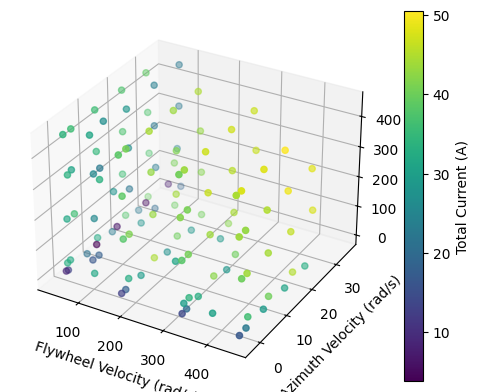

In [6]:
# Plot in 3D with velocities on each axis and current as the color
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
scat = ax.scatter(flywheel_vel, azimuth_vel, hood_vel, c=total_current, cmap="viridis")
ax.set_xlabel("Flywheel Velocity (rad/s)")
ax.set_ylabel("Azimuth Velocity (rad/s)")
ax.set_zlabel("Hood Velocity (rad/s)")
fig.colorbar(scat, label="Total Current (A)")
plt.show()

In [7]:
# Interactive plot with the ability to rotate and zoom
import plotly.express as px

fig = px.scatter_3d(
    x=flywheel_vel,
    y=azimuth_vel,
    z=hood_vel,
    color=total_current,
    labels={
        "x": "Flywheel Velocity (rad/s)",
        "y": "Azimuth Velocity (rad/s)",
        "z": "Hood Velocity (rad/s)",
        "color": "Total Current (A)",
        "hover_data": "Current (A)",
    },
    # Individual currents
    hover_data={
        "Flywheel Current (A)": flywheel_current,
        "Azimuth Current (A)": azimuth_current,
        "Hood Current (A)": hood_current,
    },
    title="Turret Motor Velocities and Currents"
)
fig.show()

In [10]:
# Compute R^2 score for the model
from sklearn.metrics import r2_score

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import polars as pd

def score_model_r2(current_set: pd.Series, poly: PolynomialFeatures, model: LinearRegression):
    X_poly = poly.transform(X)
    y_pred = model.predict(X_poly)
    return r2_score(current_set, y_pred)

In [11]:
# 2D cross-section (flywheel vs azimuth) with a slider for hood velocity
import numpy as np
import plotly.graph_objects as go

# Predict total current for a grid of velocities
def visualize(current_set: pd.Series, poly: PolynomialFeatures, model: LinearRegression):
    flywheel_vel_grid = np.linspace(flywheel_vel.min(), flywheel_vel.max(), 32)
    azimuth_vel_grid = np.linspace(azimuth_vel.min(), azimuth_vel.max(), 32)
    hood_vel_grid = np.linspace(hood_vel.min(), hood_vel.max(), 32)

    flywheel_vel_grid, azimuth_vel_grid, hood_vel_grid = np.meshgrid(flywheel_vel_grid, azimuth_vel_grid, hood_vel_grid)

    X_grid = pd.DataFrame({
        "flywheel_vel": flywheel_vel_grid.flatten(),
        "azimuth_vel": azimuth_vel_grid.flatten(),
        "hood_vel": hood_vel_grid.flatten(),
    })

    X_grid_poly = poly.transform(X_grid)
    y_grid_pred = model.predict(X_grid_poly)

    # Plot the predicted surface
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    # Squares to represent real data and circles to represent the model
    vmin = 0
    # vmax = 100
    vmax = max(current_set.max(), y_grid_pred.max())
    scat = ax.scatter(flywheel_vel, azimuth_vel, hood_vel, c=current_set, cmap="viridis", label="Data", marker="s", vmin=vmin, vmax=vmax)
    ax.scatter(X_grid["flywheel_vel"], X_grid["azimuth_vel"], X_grid["hood_vel"], c=y_grid_pred, cmap="viridis", label="Model", marker="o", vmin=vmin, vmax=vmax, alpha=0.02)

    ax.set_xlabel("Flywheel Velocity (rad/s)")
    ax.set_ylabel("Azimuth Velocity (rad/s)")
    ax.set_zlabel("Hood Velocity (rad/s)")
    ax.legend()
    plt.show()

    # flattened grid arrays and predictions (already exist in the notebook)
    fx = flywheel_vel_grid.flatten()
    ax = hood_vel_grid.flatten()
    hx = azimuth_vel_grid.flatten()
    pred = y_grid_pred

    # unique hood levels (slider steps)
    hood_levels = np.unique(hx)

    # build one trace per hood slice (only the first visible initially)
    pred_traces = []
    for i, h in enumerate(hood_levels):
        mask = hx == h
        pred_traces.append(go.Scatter(
            x=fx[mask],
            y=ax[mask],
            mode="markers",
            marker=dict(
                color=pred[mask],
                colorscale="Viridis",
                cmin=vmin,
                cmax=vmax,
                size=6
            ),
            name=f"Model (azimuth={h:06.2f})",
            visible=(i == 0),
            hovertemplate="Flywheel: %{x:.1f}<br>Hood: %{y:.1f}<br>Pred: %{marker.color:.2f}<extra></extra>",
        ))

        # Actual data, with opacity scaled by how close the data slice is to our slice
        pred_traces.append(go.Scatter(
            x=flywheel_vel,
            y=hood_vel,
            mode="markers",
            marker=dict(
                color=total_current,
                colorscale="Viridis",
                cmin=vmin,
                cmax=vmax,
                size=8,
                opacity=np.exp(-((azimuth_vel - h) ** 2) / (2 * 8**2))
            ),
            name="Data",
            hovertemplate="Flywheel: %{x:.1f}<br>Hood: %{y:.1f}<br>Total Current: %{marker.color:.2f}<extra></extra>",
        ))

    fig2d = go.Figure(data=pred_traces)

    # slider steps: toggle visibility of the model traces, keep data_trace visible
    steps = []
    n_model = len(pred_traces)
    for i, h in enumerate(hood_levels):
        vis = [False] * n_model
        vis[2 * i] = True  # model trace for this hood slice
        vis[2 * i + 1] = True  # data trace
        steps.append(
            dict(
                method="update",
                args=[{"visible": vis}, {"title": f"Azimuth slice = {h:3.1f}"}],
                label=f"{h:.0f}",
            )
        )

    sliders = [dict(active=0, currentvalue={"prefix": "Azimuth = "}, pad={"t": 10}, steps=steps)]

    fig2d.update_layout(
        title=f"Hood slice = {hood_levels[0]:.1f}",
        xaxis_title="Flywheel Velocity (rad/s)",
        yaxis_title="Hood Velocity (rad/s)",
        sliders=sliders,
        height=800,
        width=1050
    )

    fig2d.show()

In [12]:
def log_model_info(model_name: str, current_set: pd.Series, poly: PolynomialFeatures, model: LinearRegression):
    print(f"{model_name}:")
    equation = create_equation(poly, model)
    print(f"  Model equation: {equation}")

    r2 = score_model_r2(current_set, poly, model)
    print(f"  R^2 score: {r2:.4f}")

In [13]:
# Fit for each of the three current sets
flywheel_poly, flywheel_model = fit_model(flywheel_current)
azimuth_poly, azimuth_model = fit_model(azimuth_current)
hood_poly, hood_model = fit_model(hood_current)
total_poly, total_model = fit_model(total_current)

log_model_info("Flywheel Current", flywheel_current, flywheel_poly, flywheel_model)
log_model_info("Azimuth Current", azimuth_current, azimuth_poly, azimuth_model)
log_model_info("Hood Current", hood_current, hood_poly, hood_model)

Flywheel Current:
  Model equation: y = 4.50954981 + 0.03933206 * flywheel_vel + -0.17261779 * azimuth_vel + -0.01129331 * hood_vel + -0.00003148 * flywheel_vel^2 + 0.00049094 * flywheel_vel * azimuth_vel + 0.00001568 * flywheel_vel * hood_vel + 0.00037112 * azimuth_vel^2 + 0.00000077 * azimuth_vel * hood_vel + 0.00001883 * hood_vel^2
  R^2 score: 0.6279
Azimuth Current:
  Model equation: y = 3.13158136 + 0.01567187 * flywheel_vel + 0.56797553 * azimuth_vel + -0.03258733 * hood_vel + -0.00002328 * flywheel_vel^2 + 0.00038505 * flywheel_vel * azimuth_vel + -0.00000128 * flywheel_vel * hood_vel + -0.01541767 * azimuth_vel^2 + -0.00017302 * azimuth_vel * hood_vel + 0.00005798 * hood_vel^2
  R^2 score: 0.5555
Hood Current:
  Model equation: y = 7.49297619 + 0.00385578 * flywheel_vel + 0.17269444 * azimuth_vel + 0.11114643 * hood_vel + -0.00002058 * flywheel_vel^2 + -0.00018575 * flywheel_vel * azimuth_vel + 0.00001628 * flywheel_vel * hood_vel + 0.00064642 * azimuth_vel^2 + -0.00050922 * a

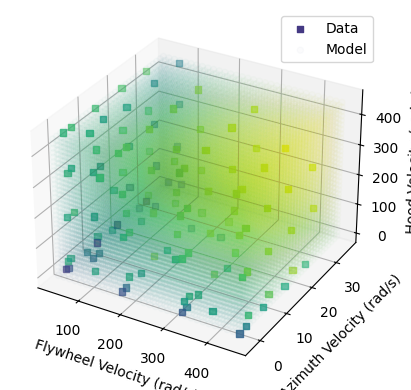

In [14]:
visualize(total_current, total_poly, total_model)